# **1. Import Libraries**

In [11]:
# --- Core Python Libraries ---
import os
import random
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# --- Image Handling ---
from PIL import Image

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Evaluation ---
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

import ipywidgets as widgets
from IPython.display import display

# **1.1 Initialize Path**

In [12]:
# Define the base directory for the dataset
base_path = 'C:/Users/awadh/Wheat/other'

# Define the paths for the training and testing data
train_path = os.path.join(base_path, 'train')
test_path = os.path.join(base_path, 'test')

# **2. Preview Data**

In [13]:
# Get all classnames from directory
class_names = sorted(os.listdir(train_path))

print("Classes:", class_names)
print("Total number of classes:", len(class_names))

Classes: ['Blast', 'Common Root Rot', 'Fusarium Head Blight', 'Healthy', 'Leaf Blight', 'Mildew', 'Septoria', 'Smut', 'Tan spot']
Total number of classes: 9


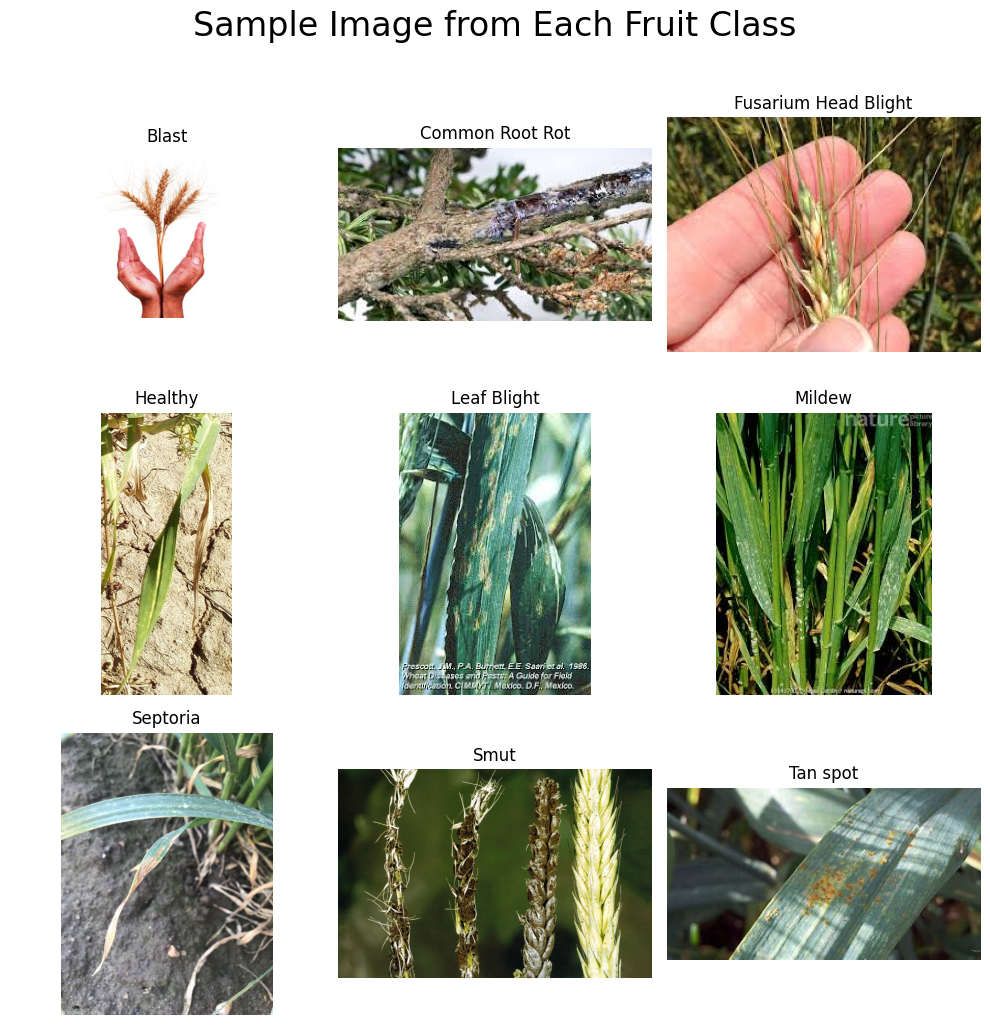

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle("Sample Image from Each Fruit Class", fontsize=24, y=1.02)
axes = axes.ravel()

valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.jfif')

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(train_path, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(valid_ext)]
    
    if image_files:
        image_path = os.path.join(class_dir, random.choice(image_files))
        img = Image.open(image_path)
        axes[i].imshow(img)
        axes[i].set_title(class_name, fontsize=12)
        axes[i].axis("off")

for j in range(len(class_names), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# **3. Data Exploration**

In [18]:
# Count images per class
class_counts = {
    cls: len(os.listdir(os.path.join(train_path, cls)))
    for cls in class_names
}

# Create DataFrame sorted by count
df_counts = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])
df_counts = df_counts.sort_values(by='Count', ascending=False)
df_counts.insert(0, 'sl.no', range(1, 1 + len(df_counts)))

print("Image counts per class:")
print(df_counts.to_string(index=False))

# Total images
total_images = df_counts['Count'].sum()
print(f"\nTotal number of images: {total_images}")

Image counts per class:
 sl.no                Class  Count
     1          Leaf Blight   1515
     2             Septoria   1357
     3                 Smut   1310
     4 Fusarium Head Blight   1149
     5              Healthy   1000
     6             Tan spot    770
     7                Blast    647
     8      Common Root Rot    614
     9               Mildew    567

Total number of images: 8929


# **4. Define and Load Data using Pipeline**

# 4.1 Preprocessing and Splitting Dataset 

In [19]:
# Image dimensions and batch size
img_width, img_height = 100, 100
batch_size = 32

# Data generator with normalization and train/validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3
)

# Training data (80%)
train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation data (20%)
validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Summary
print(f"Training images: {train_generator.n}")
print(f"Validation images: {validation_generator.n}")
print(f"Number of classes: {train_generator.num_classes}")

Found 6252 images belonging to 9 classes.
Found 2677 images belonging to 9 classes.
Training images: 6252
Validation images: 2677
Number of classes: 9


# 4.2 Data Augmentation

In [21]:
# Image dimensions and batch size
img_width, img_height = 100, 100
batch_size = 32

# Data generator with augmentation and validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.3
)

# Training data (80%)
train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation data (20%)
validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Summary
print(f"Training images: {train_generator.n}")
print(f"Validation images: {validation_generator.n}")
print(f"Number of classes: {train_generator.num_classes}")

Found 6252 images belonging to 9 classes.
Found 2677 images belonging to 9 classes.
Training images: 6252
Validation images: 2677
Number of classes: 9


# **5. Model Evaluation**

In [22]:
# Number of classes and image dimensions
num_classes = train_generator.num_classes
img_width, img_height = 100, 100

# Use MirroredStrategy for multi-GPU or robust device placement
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    model = tf.keras.Sequential([
        # Convolutional blocks
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # Flatten and fully connected layers
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 98, 98, 32)        896       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 49, 49, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 47, 47, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 23, 23, 64)       0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 21, 21, 128)       73856     
                  

In [23]:
# Define the number of training epochs
epochs = 200

# Early stopping callback to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',   
    patience=3,           
    restore_best_weights=True
)

# Start training
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

Epoch 1/200
195/195 [==============================] - 98s 499ms/step - loss: 2.0260 - accuracy: 0.2402 - val_loss: 1.9591 - val_accuracy: 0.3008
Epoch 2/200
195/195 [==============================] - 94s 480ms/step - loss: 1.8036 - accuracy: 0.3582 - val_loss: 1.7389 - val_accuracy: 0.3742
Epoch 3/200
195/195 [==============================] - 95s 484ms/step - loss: 1.5819 - accuracy: 0.4341 - val_loss: 1.5736 - val_accuracy: 0.4499
Epoch 4/200
195/195 [==============================] - 95s 488ms/step - loss: 1.4781 - accuracy: 0.4722 - val_loss: 1.4859 - val_accuracy: 0.4925
Epoch 5/200
195/195 [==============================] - 95s 489ms/step - loss: 1.3692 - accuracy: 0.5122 - val_loss: 1.4876 - val_accuracy: 0.4763
Epoch 6/200
195/195 [==============================] - 95s 487ms/step - loss: 1.3065 - accuracy: 0.5371 - val_loss: 1.4029 - val_accuracy: 0.5200
Epoch 7/200
195/195 [==============================] - 95s 488ms/step - loss: 1.2340 - accuracy: 0.5569 - val_loss: 1.4027 -

UnknownError: Graph execution error:

2 root error(s) found.
  (0) UNKNOWN:  FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/awadh/Wheat/other\\train\\Blast\\blast_3.png'
Traceback (most recent call last):

  File "C:\Users\awadh\py310\lib\site-packages\tensorflow\python\ops\script_ops.py", line 271, in __call__
    ret = func(*args)

  File "C:\Users\awadh\py310\lib\site-packages\tensorflow\python\autograph\impl\api.py", line 642, in wrapper
    return func(*args, **kwargs)

  File "C:\Users\awadh\py310\lib\site-packages\tensorflow\python\data\ops\dataset_ops.py", line 1035, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))

  File "C:\Users\awadh\py310\lib\site-packages\keras\engine\data_adapter.py", line 903, in wrapped_generator
    for data in generator_fn():

  File "C:\Users\awadh\py310\lib\site-packages\keras\engine\data_adapter.py", line 1050, in generator_fn
    yield x[i]

  File "C:\Users\awadh\py310\lib\site-packages\keras\

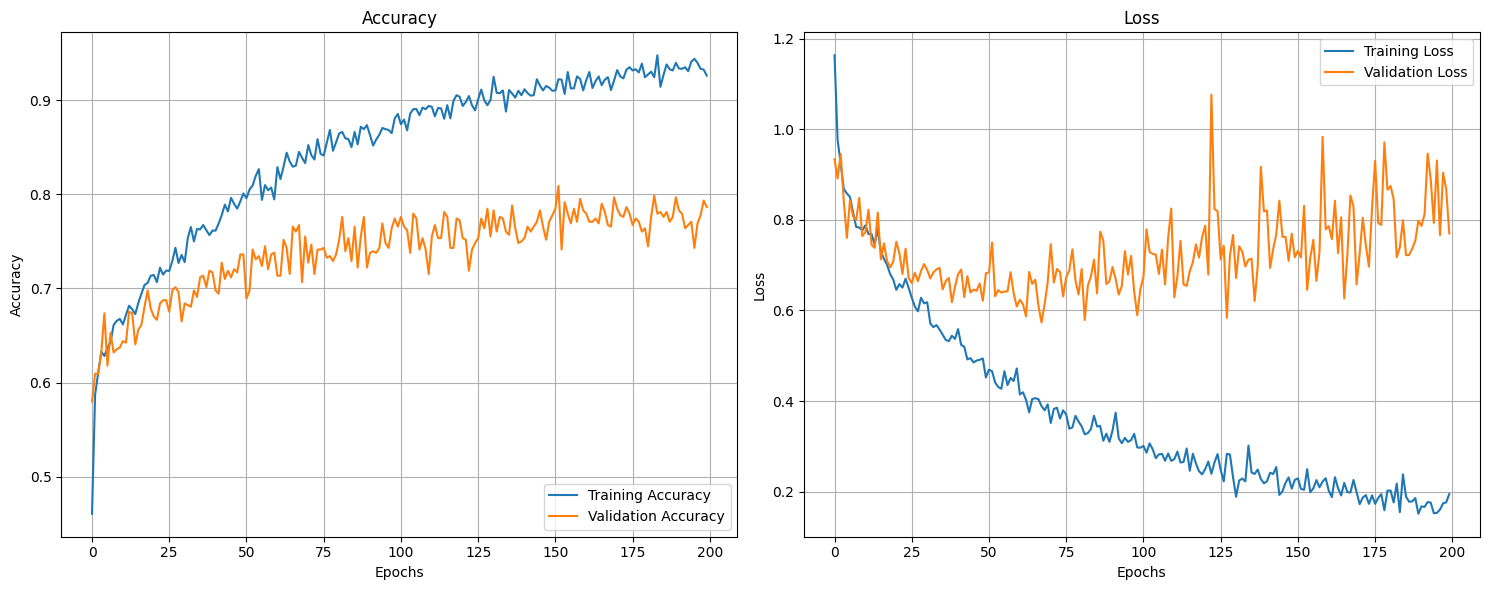

In [10]:
# Extract metrics from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Plot training and validation accuracy & loss
plt.figure(figsize=(15, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Get the final validation metrics
final_accuracy = history.history['val_accuracy'][-1]
final_loss = history.history['val_loss'][-1]

print(f"Final Validation Accuracy: {final_accuracy:.4f}")
print(f"Final Validation Loss: {final_loss:.4f}")

Final Validation Accuracy: 0.7865
Final Validation Loss: 0.7700


In [12]:
# Get the true labels and predicted labels for the validation set
validation_labels = validation_generator.classes
validation_steps = validation_generator.samples // validation_generator.batch_size
predictions = model.predict(validation_generator, steps=validation_steps)
predicted_labels = np.argmax(predictions, axis=1)

# Get the class labels from the generator
class_labels = list(validation_generator.class_indices.keys())

# Generate and print the classification report
report = classification_report(validation_labels[:len(predicted_labels)], predicted_labels, target_names=class_labels)
print("\nClassification Report:\n", report)

18/18 [==============================] - 5s 253ms/step

Classification Report:
               precision    recall  f1-score   support

       Aphid       0.69      0.80      0.74       189
     Healthy       0.92      0.97      0.94       200
        Mite       0.72      0.56      0.63       160
    Stem fly       0.71      0.56      0.62        27

    accuracy                           0.78       576
   macro avg       0.76      0.72      0.73       576
weighted avg       0.78      0.78      0.77       576



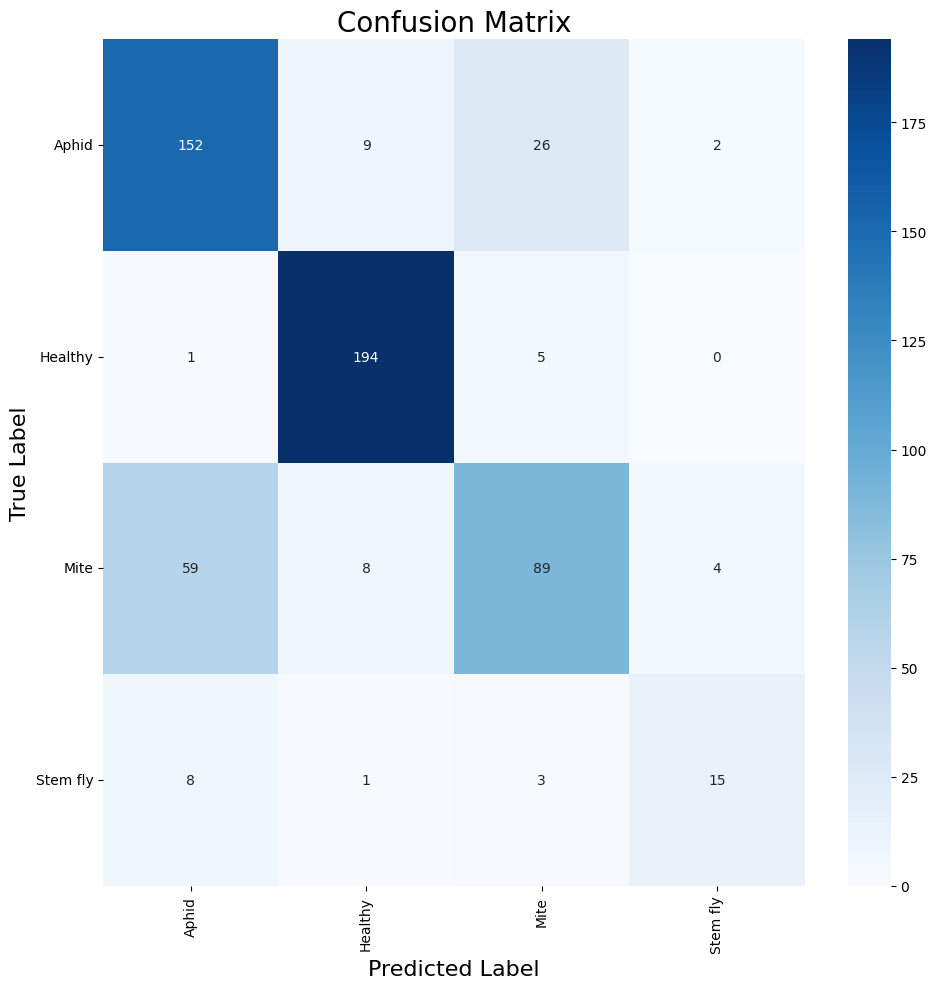

In [13]:
# Generate the confusion matrix
cm = confusion_matrix(validation_labels[:len(predicted_labels)], predicted_labels)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix', fontsize=20)
plt.xlabel('Predicted Label', fontsize=16)
plt.ylabel('True Label', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# **6. Test model with Unseen Data**

In [14]:
# Save the model in the HDF5 (.h5) format
model.save('C:/Users/awadh/Wheat/my_wheat_model.h5')
print("Model saved successfully as 'my_wheat_model.h5'.")

Model saved successfully as 'my_wheat_model.h5'.


In [15]:
# -------------------------------
# IMPORTS
# -------------------------------
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import ipywidgets as widgets
from IPython.display import display
from tensorflow.keras.models import load_model

# -------------------------------
# FORCE CPU (avoid transfer manager errors)
# -------------------------------
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# -------------------------------
# LOAD MODEL
# -------------------------------
model_path = 'C:/Users/awadh/Wheat/my_wheat_model.h5'
model = load_model(model_path, compile=False)

# -------------------------------
# CLASS LABELS
# -------------------------------
class_labels = ['Aphid', 'Healthy', 'Mite', 'Stem fly']

# -------------------------------
# IMAGE PREPROCESSING
# -------------------------------
def preprocess_image(image_path, target_size=(100, 100)):
    """Load image, resize, normalize and expand dimensions for prediction."""
    img = Image.open(image_path).convert("RGB")
    img = img.resize(target_size)
    img_array = np.array(img).astype("float32") / 255.0
    return np.expand_dims(img_array, axis=0)

# -------------------------------
# PREDICTION FUNCTION
# -------------------------------
def predict_image(img_path):
    """Predict and return figure + label instead of showing directly."""
    x = preprocess_image(img_path)
    x = tf.convert_to_tensor(x)

    with tf.device("/CPU:0"):
        preds = model(x, training=False).numpy()

    idx = np.argmax(preds, axis=1)[0]
    label = class_labels[idx]
    conf = preds[0][idx] * 100

    # Plot image
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(Image.open(img_path))
    ax.axis("off")
    ax.set_title(f"Predicted: {label} ({conf:.2f}%)", fontsize=12)

    # Return figure and details
    return fig, label, conf, os.path.basename(img_path)

# -------------------------------
# TEST IMAGE SEARCH
# -------------------------------
test_path = 'C:/Users/awadh/Wheat/Pest/test'
valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.jfif')

# Search recursively for images in subfolders
image_files = []
for root, dirs, files in os.walk(test_path):
    for f in files:
        if f.lower().endswith(valid_ext):
            image_files.append(os.path.join(root, f))

# Relative paths for dropdown display
dropdown_options = [os.path.relpath(f, test_path) for f in image_files]

print(f"✅ Found {len(image_files)} images for prediction.")

# -------------------------------
# WIDGETS
# -------------------------------
dropdown = widgets.Dropdown(
    options=dropdown_options if dropdown_options else ["(no images found)"],
    description="Choose Image:",
    layout=widgets.Layout(width="60%")
)

count_box = widgets.BoundedIntText(
    value=1,
    min=1,
    max=max(1, len(image_files)),
    step=1,
    description="How many:",
    layout=widgets.Layout(width="60%")
)

button = widgets.Button(description="Predict ✅", button_style="success")
output = widgets.Output()

# -------------------------------
# BUTTON CALLBACK
# -------------------------------
def on_submit(b):
    output.clear_output()
    with output:
        if not image_files:
            print("⚠️ No images found in the test directory.")
            return

        start_index = dropdown_options.index(dropdown.value)
        num = min(count_box.value, len(image_files) - start_index)
        selected_files = image_files[start_index:start_index + num]

        for f in selected_files:
            fig, label, conf, filename = predict_image(f)
            display(fig)
            print(f"📂 File: {filename}")
            print(f"✅ Prediction: {label} ({conf:.2f}%)\n")
            plt.close(fig)

button.on_click(on_submit)

# -------------------------------
# DISPLAY UI
# -------------------------------
display(widgets.VBox([dropdown, count_box, button, output]))


✅ Found 200 images for prediction.
